In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
possible_files = [
    "seasonal_agriculture_performance_dataset.csv",
    "Seasonal Agriculture Performance Dataset.csv",
    "seasonal_agriculture_cleaned_dataset.csv"
]

dataset_file = None

for file_name in possible_files:
    if Path(file_name).exists():
        dataset_file = file_name
        break

if dataset_file is None:
    raise FileNotFoundError(
        "Dataset file not found. Please place the CSV file in the same folder "
        "as this notebook and update the filename."
    )

df = pd.read_csv(dataset_file)

print("Dataset loaded successfully!")
print("Dataset file:", dataset_file)
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset file: seasonal_agriculture_performance_dataset.csv
Dataset shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn Names:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

print("\nDataset Information:")
df.info()

Number of rows: 4000
Number of columns: 28

Column Names:
1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-n

In [5]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",NaN,NaN,NaN,601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


In [6]:
print("MISSING VALUES")
missing_values = df.isnull().sum()
missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": (missing_values / len(df)) * 100
})

display(missing_table[missing_table["Missing Values"] > 0].sort_values(
    "Missing Values", ascending=False
))

print("Duplicate Rows:", df.duplicated().sum())

print("\nData Types:")
display(pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str)
}))

MISSING VALUES


,Missing Values,Missing Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


Duplicate Rows: 0

Data Types:


,Column,Data Type
Farm_ID,Farm_ID,object
State,State,object
District,District,object
Crop,Crop,object
Season,Season,object
Farm_Area_Hectares,Farm_Area_Hectares,float64
Rainfall_mm,Rainfall_mm,float64
Avg_Temperature_C,Avg_Temperature_C,float64
Humidity_pct,Humidity_pct,float64
Sunlight_Hours_Day,Sunlight_Hours_Day,float64


In [7]:
clean = df.copy()

# Columns identified for missing-value treatment
columns_to_clean = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

for column in columns_to_clean:
    if column in clean.columns:
        clean[column] = clean.groupby("Season")[column].transform(
            lambda x: x.fillna(x.median())
        )
        clean[column] = clean[column].fillna(clean[column].median())

# Remove duplicate rows if any exist
clean = clean.drop_duplicates().reset_index(drop=True)

print("Data cleaning completed!")
print("Final dataset shape:", clean.shape)

print("\nRemaining missing values:")
display(clean.isnull().sum()[clean.isnull().sum() > 0])

Data cleaning completed!
Final dataset shape: (4000, 28)

Remaining missing values:


,0


In [8]:
clean["Profit_Margin_pct"] = np.where(
    clean["Revenue_INR"] != 0,
    (clean["Profit_INR"] / clean["Revenue_INR"]) * 100,
    np.nan
)

# Return on Investment (ROI)
clean["ROI_pct"] = np.where(
    clean["Total_Cost_INR"] != 0,
    (clean["Profit_INR"] / clean["Total_Cost_INR"]) * 100,
    np.nan
)

# Water used per hectare
clean["Water_Used_per_Hectare"] = np.where(
    clean["Farm_Area_Hectares"] != 0,
    clean["Water_Used_m3"] / clean["Farm_Area_Hectares"],
    np.nan
)

print("New features created successfully!")

clean[[
    "Farm_ID", "Season", "Crop",
    "Revenue_INR", "Total_Cost_INR", "Profit_INR",
    "Profit_Margin_pct", "ROI_pct"
]].head()

New features created successfully!


,Farm_ID,Season,Crop,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct,ROI_pct
0,SF10001,Kharif,Wheat,30810,42662,-11852,-38.47,-27.78
1,SF10002,Kharif,Maize,40401,492351,-451950,"-1,118.66",-91.79
2,SF10003,Rabi,Pulses,190466,315210,-124744,-65.49,-39.57
3,SF10004,Kharif,Rice,200740,296444,-95704,-47.68,-32.28
4,SF10005,Zaid,Maize,193607,337959,-144352,-74.56,-42.71


,Number of Records
Season,
Kharif,1779
Rabi,1627
Zaid,594


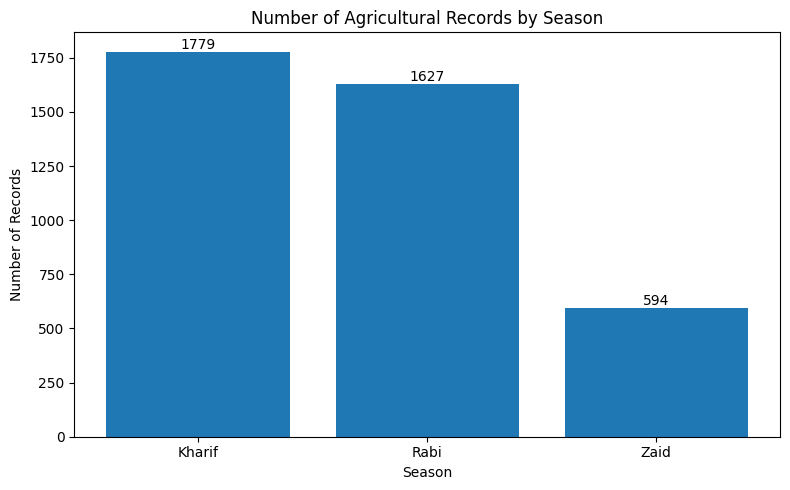

In [9]:
season_order = ["Kharif", "Rabi", "Zaid"]

season_counts = clean["Season"].value_counts().reindex(season_order)

display(season_counts.to_frame(name="Number of Records"))

plt.figure(figsize=(8, 5))
plt.bar(season_counts.index, season_counts.values)
plt.title("Number of Agricultural Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")

for i, value in enumerate(season_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [10]:
season_summary = clean.groupby("Season").agg(
    Farms=("Farm_ID", "count"),
    Average_Yield_t_ha=("Yield_Tonnes_Ha", "mean"),
    Total_Production_tonnes=("Production_Tonnes", "sum"),
    Total_Revenue_INR=("Revenue_INR", "sum"),
    Total_Cost_INR=("Total_Cost_INR", "sum"),
    Total_Profit_INR=("Profit_INR", "sum"),
    Average_Rainfall_mm=("Rainfall_mm", "mean"),
    Average_Temperature_C=("Avg_Temperature_C", "mean"),
    Average_Soil_Moisture_pct=("Soil_Moisture_pct", "mean"),
    Average_Water_Used_m3=("Water_Used_m3", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Disease_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean")
).reindex(season_order)

season_summary["Profit_Margin_pct"] = (
    season_summary["Total_Profit_INR"] /
    season_summary["Total_Revenue_INR"] * 100
)

season_summary["ROI_pct"] = (
    season_summary["Total_Profit_INR"] /
    season_summary["Total_Cost_INR"] * 100
)

season_summary.round(2)


,Farms,Average_Yield_t_ha,Total_Production_tonnes,Total_Revenue_INR,Total_Cost_INR,Total_Profit_INR,Average_Rainfall_mm,Average_Temperature_C,Average_Soil_Moisture_pct,Average_Water_Used_m3,Average_Water_Efficiency,Average_Disease_Pest_Risk_pct,Profit_Margin_pct,ROI_pct
Season,,,,,,,,,,,,,,
Kharif,1779,5.63,"82,387.61",1264369200,946080042,318289158,852.11,28.45,31.20,"6,102.20",5.89,54.47,25.17,33.64
Rabi,1627,5.04,"67,498.88",978682881,836012113,142670768,435.94,23.49,24.05,"5,846.99",5.19,40.48,14.58,17.07
Zaid,594,4.64,"23,098.35",308388111,323122177,-14734066,299.12,31.04,19.17,"6,419.89",4.41,38.22,-4.78,-4.56


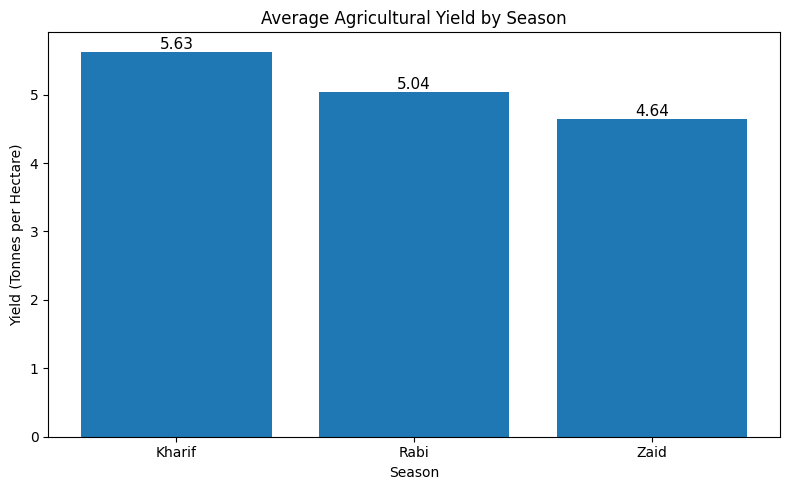

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    season_summary.index,
    season_summary["Average_Yield_t_ha"]
)

plt.title("Average Agricultural Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes per Hectare)")

for i, value in enumerate(season_summary["Average_Yield_t_ha"]):
    plt.text(i, value, f"{value:.2f}",
             ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

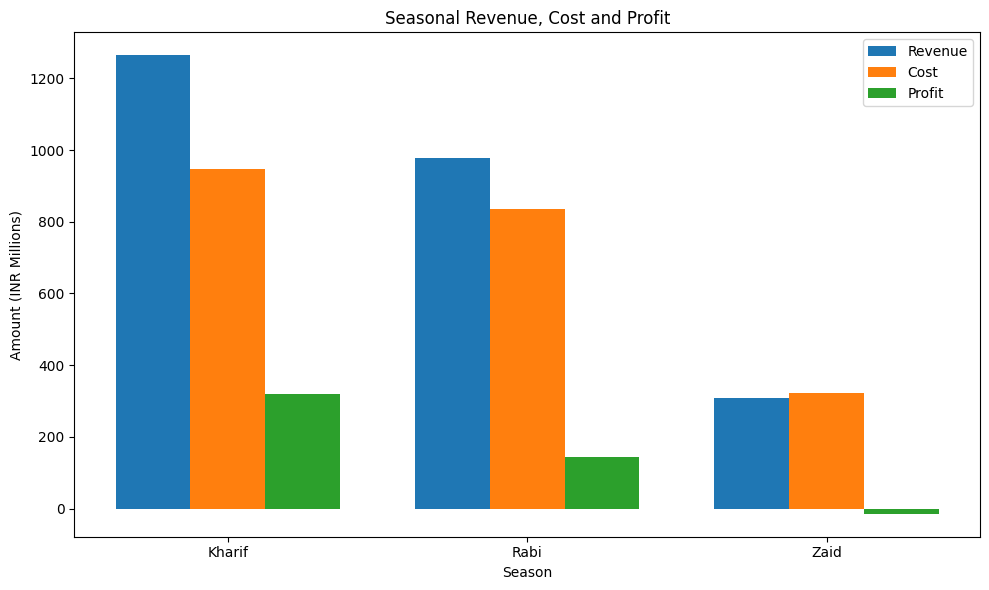

In [12]:
x = np.arange(len(season_order))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(
    x - width,
    season_summary["Total_Revenue_INR"] / 1_000_000,
    width,
    label="Revenue"
)

plt.bar(
    x,
    season_summary["Total_Cost_INR"] / 1_000_000,
    width,
    label="Cost"
)

plt.bar(
    x + width,
    season_summary["Total_Profit_INR"] / 1_000_000,
    width,
    label="Profit"
)

plt.xticks(x, season_order)
plt.title("Seasonal Revenue, Cost and Profit")
plt.xlabel("Season")
plt.ylabel("Amount (INR Millions)")
plt.legend()

plt.tight_layout()
plt.show()

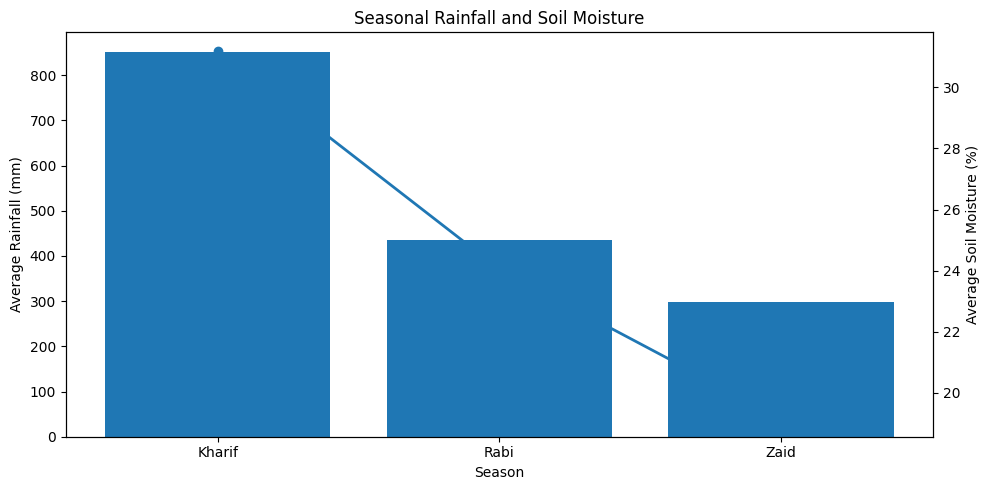

In [13]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    season_summary.index,
    season_summary["Average_Rainfall_mm"]
)
ax1.set_xlabel("Season")
ax1.set_ylabel("Average Rainfall (mm)")

ax2 = ax1.twinx()
ax2.plot(
    season_summary.index,
    season_summary["Average_Soil_Moisture_pct"],
    marker="o",
    linewidth=2
)
ax2.set_ylabel("Average Soil Moisture (%)")

plt.title("Seasonal Rainfall and Soil Moisture")
fig.tight_layout()
plt.show()

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,"954,380.42","638,572.50","448,659.09"
Cotton,"216,999.55","107,343.59","-53,925.34"
Groundnut,"108,265.44","10,416.54","-68,872.50"
Maize,"-39,332.67","-89,133.40","-194,049.17"
Pulses,"43,338.90","-14,309.14","-139,227.81"
Rice,"-64,903.40","-98,427.87","-227,239.34"
Sugarcane,"1,000,790.81","731,612.86","583,635.80"
Wheat,"-105,871.87","-119,954.57","-193,208.95"


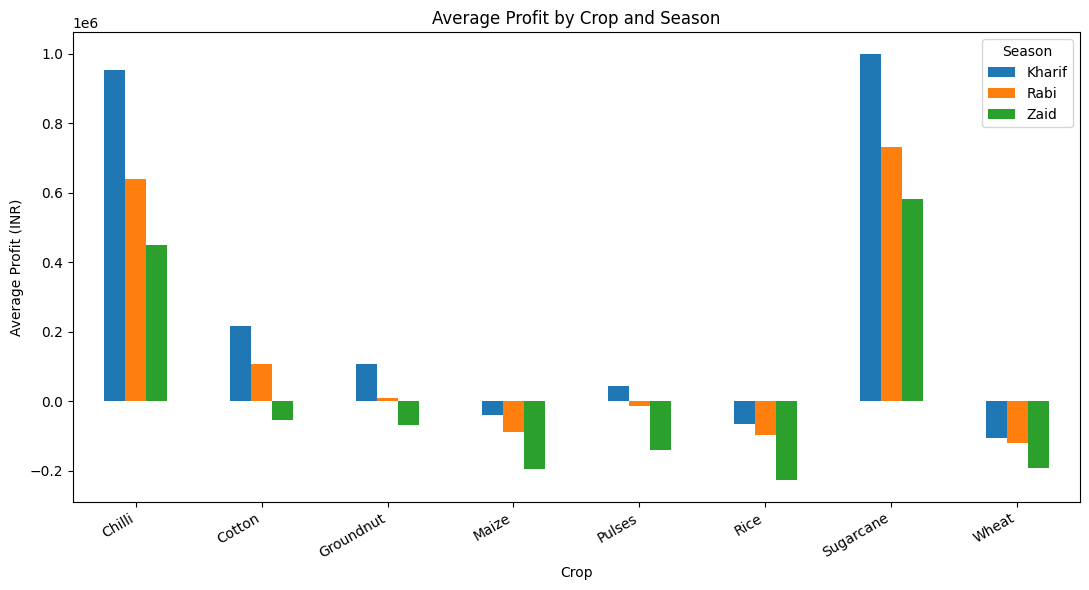

In [16]:
crop_summary = clean.groupby("Crop").agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Production=("Production_Tonnes", "mean")
).sort_values("Total_Profit", ascending=False)

crop_summary.round(2)


crop_profit = clean.pivot_table(
    index="Crop",
    columns="Season",
    values="Profit_INR",
    aggfunc="mean"
).reindex(columns=season_order)

display(crop_profit.round(2))

crop_profit.plot(kind="bar", figsize=(11, 6))

plt.title("Average Profit by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Season")

plt.tight_layout()
plt.show()

In [17]:
crop_season_summary = clean.groupby(
    ["Season", "Crop"]
).agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Risk=("Disease_Pest_Risk_pct", "mean")
).sort_values("Average_Profit", ascending=False)

crop_season_summary.round(2).head(15)

Farms  Average_Yield  Average_Profit  Total_Profit  \
Season Crop                                                            
Kharif Sugarcane    125          53.46    1,000,790.81     125098851   
       Chilli       185           1.73      954,380.42     176560378   
Rabi   Sugarcane    129          43.28      731,612.86      94378059   
       Chilli       163           1.46      638,572.50     104087317   
Zaid   Sugarcane     51          38.42      583,635.80      29765426   
       Chilli        64           1.19      448,659.09      28714182   
Kharif Cotton       215           1.38      216,999.55      46654903   
       Groundnut    193           1.49      108,265.44      20895230   
Rabi   Cotton       201           1.20      107,343.59      21576061   
Kharif Pulses       221           1.04       43,338.90       9577896   
Rabi   Groundnut    177           1.23       10,416.54       1843728   
       Pulses       213           0.88      -14,309.14      -3047846   
Kharif Maize        234           2.97      -39,332.67      -9203845   
Zaid   Cotton        92           0.96      -53,925.34      -4961131   
Kharif Rice         314           2.70      -64,903.40     -20379669   

                  Average_Risk  
Season Crop                     
Kharif Sugarcane         54.02  
       Chilli            52.81  
Rabi   Sugarcane         39.85  
       Chilli            40.59  
Zaid   Sugarcane         38.35  
       Chilli            40.50  
Kharif Cotton            54.24  
       Groundnut         54.28  
Rabi   Cotton            41.54  
Kharif Pulses            54.96  
Rabi   Groundnut         39.76  
       Pulses            40.08  
Kharif Maize             54.82  
Zaid   Cotton            36.34  
Kharif Rice              54.25

Farms  Average_Yield  Average_Profit  \
Season Irrigation_Method                                         
Kharif Drip                 405           7.26      317,222.07   
       Flood                590           4.98      133,373.83   
       Rainfed              463           5.70      158,974.13   
       Sprinkler            321           4.66      116,880.49   
Rabi   Drip                 370           6.11      187,843.22   
       Flood                526           5.06       58,824.80   
       Rainfed              438           3.93       45,232.48   
       Sprinkler            293           5.31       76,502.07   
Zaid   Drip                 140           5.85       21,291.84   
       Flood                194           3.98      -69,786.78   
       Rainfed              140           3.06      -79,467.26   
       Sprinkler            120           6.13       57,909.40   

                          Average_Water_Efficiency  Average_Water_Used  
Season Irrigation_Method                                                
Kharif Drip                                   6.80            5,953.37  
       Flood                                  3.64            8,229.27  
       Rainfed                                8.85            3,687.52  
       Sprinkler                              4.62            5,863.27  
Rabi   Drip                                   6.05            5,911.41  
       Flood                                  3.48            7,766.83  
       Rainfed                                6.87            3,298.29  
       Sprinkler                              4.64            6,129.09  
Zaid   Drip                                   5.30            5,837.99  
       Flood                                  2.73            8,113.69  
       Rainfed                                5.48            3,879.39  
       Sprinkler                              4.86            7,324.41

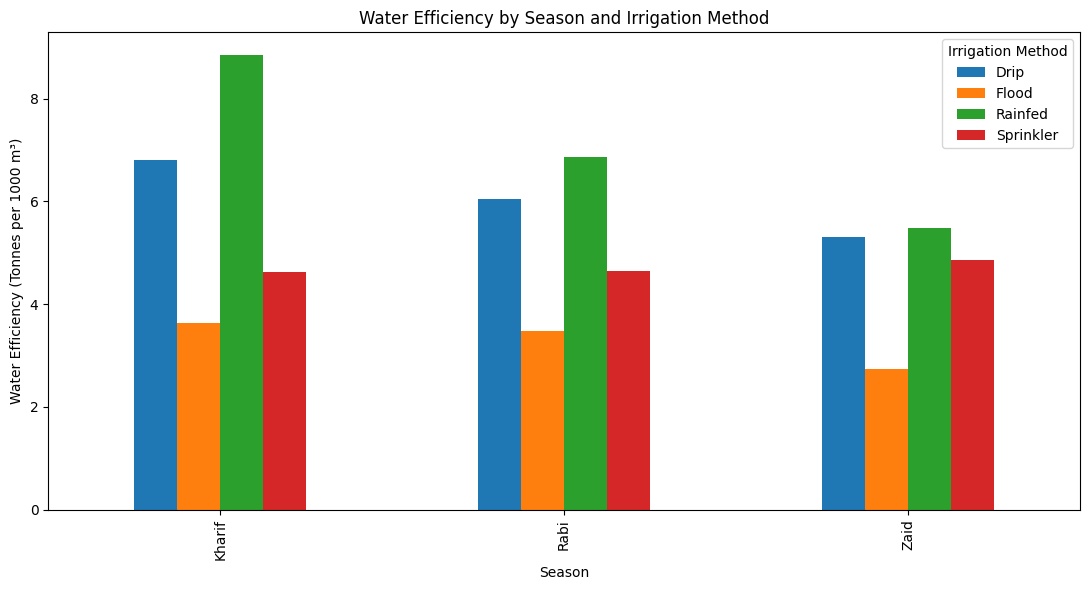

In [18]:
irrigation_summary = clean.groupby(
    ["Season", "Irrigation_Method"]
).agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

display(irrigation_summary)

water_efficiency_pivot = irrigation_summary[
    "Average_Water_Efficiency"
].unstack().reindex(season_order)

water_efficiency_pivot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Water Efficiency by Season and Irrigation Method")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.legend(title="Irrigation Method")

plt.tight_layout()
plt.show()

In [19]:
state_summary = clean.groupby("State").agg(
    Farms=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3", "mean")
).sort_values("Total_Profit", ascending=False)

state_summary.round(2)

,Farms,Average_Yield,Average_Profit,Total_Profit,Average_Water_Efficiency
State,,,,,
Maharashtra,512,5.02,"135,428.86",69339574,5.28
Punjab,484,6.12,"136,025.64",65836408,5.62
Karnataka,489,5.69,"119,422.34",58397522,5.56
Gujarat,488,5.66,"117,568.24",57373299,5.58
Tamil Nadu,485,4.87,"117,744.75",57106203,5.31
Telangana,516,5.04,"108,829.62",56156082,5.46
Madhya Pradesh,497,4.99,"86,840.76",43159856,5.27
Andhra Pradesh,529,4.63,"73,453.53",38856916,5.03


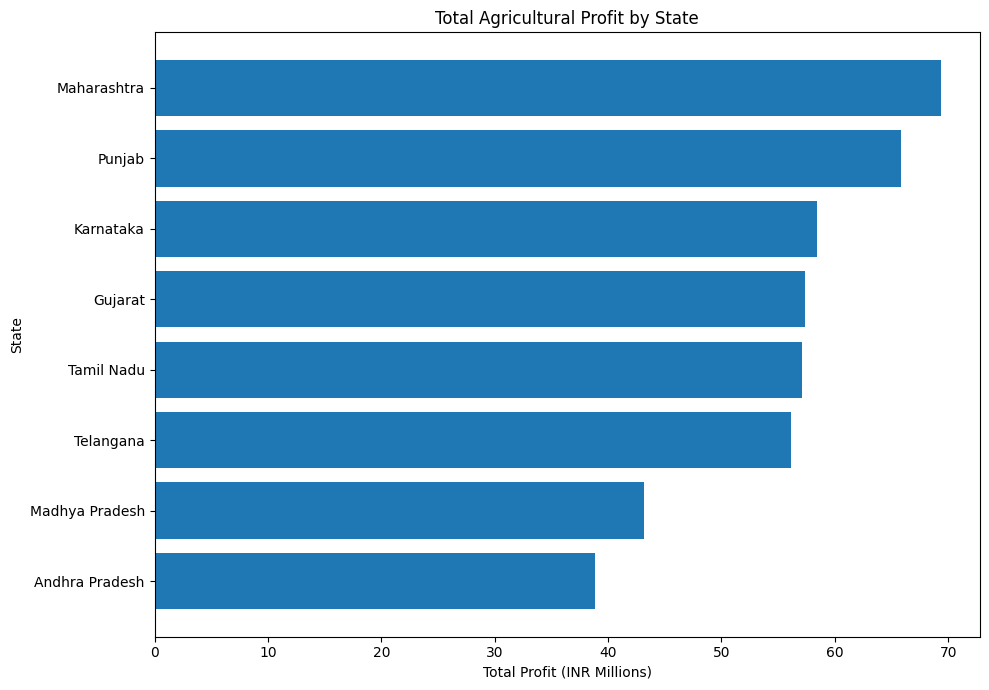

In [20]:
state_profit = state_summary["Total_Profit"].sort_values()

plt.figure(figsize=(10, 7))
plt.barh(
    state_profit.index,
    state_profit.values / 1_000_000
)

plt.title("Total Agricultural Profit by State")
plt.xlabel("Total Profit (INR Millions)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [21]:
environmental_columns = [
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Humidity_pct",
    "Sunlight_Hours_Day",
    "Soil_pH",
    "Soil_Moisture_pct",
    "Nitrogen_kg_ha",
    "Phosphorus_kg_ha",
    "Potassium_kg_ha",
    "Fertilizer_kg_ha",
    "Pesticide_Litre_ha",
    "Seed_Quality_Score",
    "Water_Used_m3",
    "Disease_Pest_Risk_pct"
]

available_columns = [
    column for column in environmental_columns
    if column in clean.columns
]

yield_correlation = (
    clean[available_columns + ["Yield_Tonnes_Ha"]]
    .corr(numeric_only=True)["Yield_Tonnes_Ha"]
    .drop("Yield_Tonnes_Ha")
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

yield_correlation.round(3)

,Yield_Tonnes_Ha
Water_Used_m3,0.39
Nitrogen_kg_ha,0.05
Phosphorus_kg_ha,0.05
Rainfall_mm,0.03
Soil_pH,-0.02
Sunlight_Hours_Day,-0.01
Disease_Pest_Risk_pct,0.01
Humidity_pct,0.01
Soil_Moisture_pct,0.01
Avg_Temperature_C,0.01


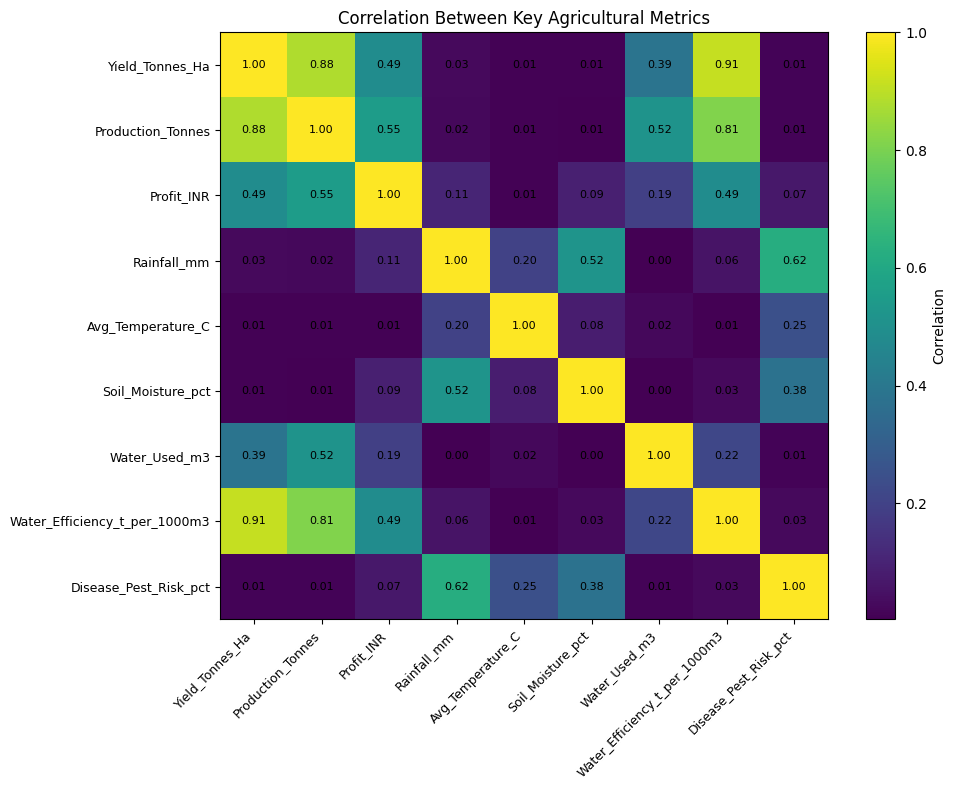

In [22]:
correlation_columns = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation_columns = [
    column for column in correlation_columns
    if column in clean.columns
]

corr_matrix = clean[correlation_columns].corr()

plt.figure(figsize=(10, 8))

image = plt.imshow(corr_matrix.values, aspect="auto")
plt.colorbar(image, label="Correlation")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right",
    fontsize=9
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns,
    fontsize=9
)

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Between Key Agricultural Metrics")
plt.tight_layout()
plt.show()

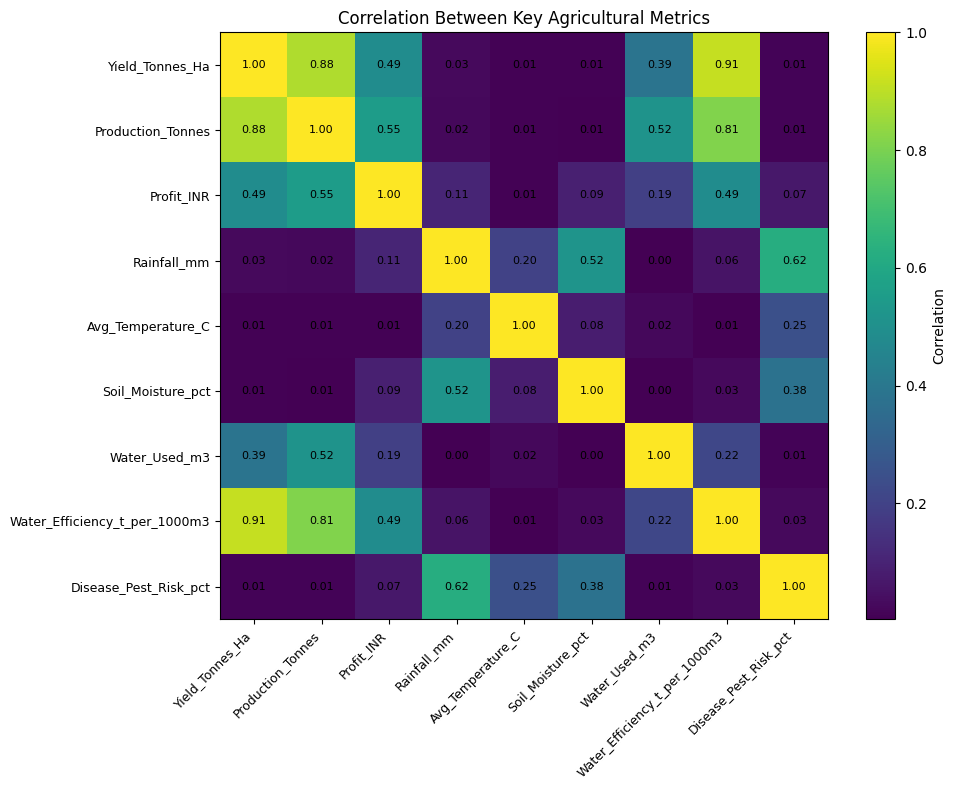

In [23]:
correlation_columns = [
    "Yield_Tonnes_Ha",
    "Production_Tonnes",
    "Profit_INR",
    "Rainfall_mm",
    "Avg_Temperature_C",
    "Soil_Moisture_pct",
    "Water_Used_m3",
    "Water_Efficiency_t_per_1000m3",
    "Disease_Pest_Risk_pct"
]

correlation_columns = [
    column for column in correlation_columns
    if column in clean.columns
]

corr_matrix = clean[correlation_columns].corr()

plt.figure(figsize=(10, 8))

image = plt.imshow(corr_matrix.values, aspect="auto")
plt.colorbar(image, label="Correlation")

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right",
    fontsize=9
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns,
    fontsize=9
)

for i in range(len(correlation_columns)):
    for j in range(len(correlation_columns)):
        plt.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.title("Correlation Between Key Agricultural Metrics")
plt.tight_layout()
plt.show()

In [24]:
profitability_summary = clean.groupby("Season").agg(
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Profit_Margin=("Profit_Margin_pct", "mean"),
    Average_ROI=("ROI_pct", "mean")
).reindex(season_order)

profitability_summary.round(2)


,Average_Revenue,Average_Cost,Average_Profit,Average_Profit_Margin,Average_ROI
Season,,,,,
Kharif,"710,719.06","531,804.41","178,914.65",-38.64,35.45
Rabi,"601,526.05","513,836.58","87,689.47",-44.27,17.60
Zaid,"519,171.90","543,976.73","-24,804.82",-69.35,-2.47


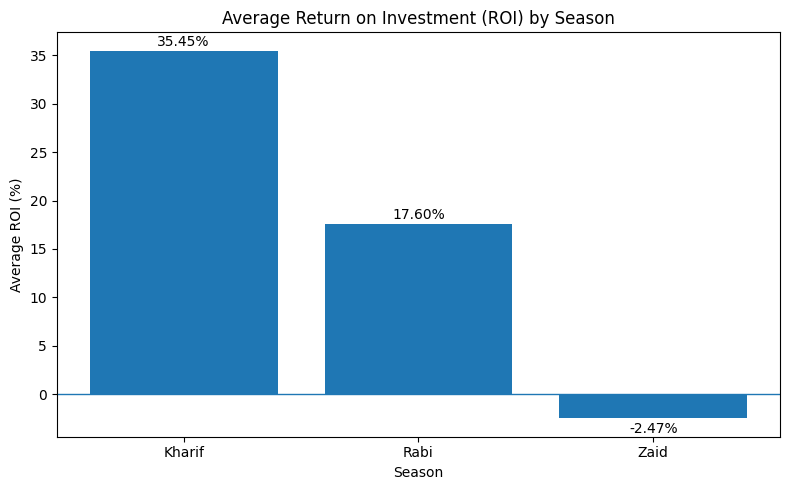

In [25]:
plt.figure(figsize=(8, 5))

plt.bar(
    profitability_summary.index,
    profitability_summary["Average_ROI"]
)

plt.axhline(0, linewidth=1)

plt.title("Average Return on Investment (ROI) by Season")
plt.xlabel("Season")
plt.ylabel("Average ROI (%)")

for i, value in enumerate(profitability_summary["Average_ROI"]):
    offset = 0.5 if value >= 0 else -1.5
    plt.text(
        i, value + offset,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [26]:
best_yield_season = season_summary["Average_Yield_t_ha"].idxmax()
best_profit_season = season_summary["Total_Profit_INR"].idxmax()
worst_profit_season = season_summary["Total_Profit_INR"].idxmin()

best_state = state_summary["Total_Profit"].idxmax()

best_crop_season = crop_season_summary["Average_Profit"].idxmax()
best_crop_season_profit = crop_season_summary.loc[
    best_crop_season, "Average_Profit"
]

highest_risk_season = season_summary[
    "Average_Disease_Pest_Risk_pct"
].idxmax()

print("KEY INSIGHTS")
print("=" * 60)

print(
    f"1. Highest average yield season: {best_yield_season} "
    f"({season_summary.loc[best_yield_season, 'Average_Yield_t_ha']:.2f} tonnes/hectare)"
)

print(
    f"2. Most profitable season: {best_profit_season} "
    f"(₹{season_summary.loc[best_profit_season, 'Total_Profit_INR']:,.0f})"
)

print(
    f"3. Lowest total profit season: {worst_profit_season} "
    f"(₹{season_summary.loc[worst_profit_season, 'Total_Profit_INR']:,.0f})"
)

print(
    f"4. Best performing state by total profit: {best_state} "
    f"(₹{state_summary.loc[best_state, 'Total_Profit']:,.0f})"
)

print(
    f"5. Best crop-season combination by average profit: "
    f"{best_crop_season[1]} in {best_crop_season[0]} "
    f"(₹{best_crop_season_profit:,.0f})"
)

print(
    f"6. Highest disease/pest risk season: {highest_risk_season} "
    f"({season_summary.loc[highest_risk_season, 'Average_Disease_Pest_Risk_pct']:.2f}%)"
)

KEY INSIGHTS
1. Highest average yield season: Kharif (5.63 tonnes/hectare)
2. Most profitable season: Kharif (₹318,289,158)
3. Lowest total profit season: Zaid (₹-14,734,066)
4. Best performing state by total profit: Maharashtra (₹69,339,574)
5. Best crop-season combination by average profit: Sugarcane in Kharif (₹1,000,791)
6. Highest disease/pest risk season: Kharif (54.47%)


In [27]:
# Save cleaned dataset
clean.to_csv("seasonal_agriculture_cleaned_dataset.csv", index=False)

# Save seasonal summary
season_summary.round(2).to_csv("seasonal_performance_summary.csv")

# Save state summary
state_summary.round(2).to_csv("state_performance_summary.csv")

# Save crop summary
crop_summary.round(2).to_csv("crop_performance_summary.csv")

print("Analysis files exported successfully!")

Analysis files exported successfully!
